# Multi-Disease Chest X-ray Classifier — Training
### MobileNetV2 transfer learning | Normal, TB, Pneumonia, Pneumothorax, COPD

Tuned for your hardware: i5-10300H, **GTX 1650 4GB**, 8GB RAM.

**Why MobileNetV2:** it's ~14MB / 3.5M params (vs. VGG16's 138M), trains 3-4x
faster on small GPUs, and needs far less VRAM — this matters a lot on a 4GB card.

**This notebook assumes** you've already run the preprocessing notebook and have:

```
multi_disease_dataset/
    train/  Normal/ TB/ Pneumonia/ Pneumothorax/ COPD/
    val/    Normal/ TB/ Pneumonia/ Pneumothorax/ COPD/
    test/   Normal/ TB/ Pneumonia/ Pneumothorax/ COPD/
```

**What this notebook does:**
1. Configures the GPU to avoid out-of-memory crashes
2. Loads train/val/test sets
3. Computes class weights to handle imbalance (since Pneumonia/Pneumothorax/COPD
   are likely much smaller than Normal/TB)
4. Builds a MobileNetV2-based model with a frozen base (fast, low VRAM)
5. Trains it, with early stopping and checkpointing
6. Optionally fine-tunes the last few layers for extra accuracy
7. Evaluates on the test set (classification report + confusion matrix)
8. Saves the final model to disk


## 1. Imports

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [5]:
print("keras version:", keras.__version__)

keras version: 3.15.1


## 2. GPU configuration (important for your 4GB card)

By default TensorFlow tries to grab **all** GPU memory upfront, which will
crash on a 4GB card once the model + batch data don't fit. `set_memory_growth`
tells it to allocate memory gradually instead — always run this cell before
anything else touches the GPU.


In [6]:
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled — GPU memory will be allocated gradually.")
    except RuntimeError as e:
        print("Could not set memory growth (must be done before GPU is initialized):", e)
else:
    print("⚠️  No GPU detected — training will run on CPU and be significantly slower.")
    print("    Check your CUDA/cuDNN install and that tensorflow-gpu is set up correctly.")


GPUs detected: []
⚠️  No GPU detected — training will run on CPU and be significantly slower.
    Check your CUDA/cuDNN install and that tensorflow-gpu is set up correctly.


## 3. Configuration

In [7]:
DATA_DIR = "./multi_disease_dataset"   # <-- change if your preprocessed folder is elsewhere

IMG_SIZE = 224
BATCH_SIZE = 16          # keep at 16 for a 4GB card; drop to 8 if you hit OOM errors
EPOCHS_FROZEN = 20       # training with frozen MobileNetV2 base
EPOCHS_FINETUNE = 10     # optional fine-tuning stage (unfreezes last layers)

MODEL_SAVE_PATH = "./best_model.keras"

CLASS_NAMES = ["COPD", "Normal", "Pneumonia", "Pneumothorax", "TB"]
# NOTE: image_dataset_from_directory sorts class folders alphabetically,
# so this order will be confirmed/overwritten automatically in the next cell —
# don't hand-edit this list, just leave it as a placeholder.


## 4. Load train / val / test datasets

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print("Class names (alphabetical order used by Keras):", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)


Found 1525 files belonging to 5 classes.
Found 372 files belonging to 5 classes.
Found 376 files belonging to 5 classes.
Class names (alphabetical order used by Keras): ['COPD', 'Normal', 'Pneumonia', 'Pneumothorax', 'TB']
Number of classes: 5


## 5. Compute class weights (handles imbalance)

Since Pneumonia/Pneumothorax/COPD are almost certainly smaller than Normal/TB
in your dataset, we weight the loss function so the model doesn't just learn
to always predict the majority classes.


In [9]:
# Count images per class directly from the train folder (fast + exact)
train_dir = os.path.join(DATA_DIR, "train")
class_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in CLASS_NAMES}
print("Training images per class:", class_counts)

# Build a flat array of integer labels matching class_counts, to compute weights
labels_flat = []
for idx, c in enumerate(CLASS_NAMES):
    labels_flat += [idx] * class_counts[c]
labels_flat = np.array(labels_flat)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=labels_flat
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}

print("\nComputed class weights:")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:14s}: {class_weight_dict[i]:.3f}")


Training images per class: {'COPD': 29, 'Normal': 1047, 'Pneumonia': 10, 'Pneumothorax': 80, 'TB': 359}

Computed class weights:
  COPD          : 10.517
  Normal        : 0.291
  Pneumonia     : 30.500
  Pneumothorax  : 3.812
  TB            : 0.850


## 6. Data augmentation + preprocessing pipeline

Applied only during training (not to val/test) to reduce overfitting on the
smaller classes. `preprocess_input` scales pixels the way MobileNetV2 expects
(it's not simple 0-1 rescaling — it matches ImageNet's original preprocessing).


In [10]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def prepare(ds, training=False):
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds_prepped = prepare(train_ds, training=True)
val_ds_prepped   = prepare(val_ds, training=False)
test_ds_prepped  = prepare(test_ds, training=False)

print("Datasets prepared with augmentation + MobileNetV2 preprocessing.")


Datasets prepared with augmentation + MobileNetV2 preprocessing.


## 7. Build the model (frozen MobileNetV2 base)

- Base: MobileNetV2 pretrained on ImageNet, **frozen** (no gradient updates) —
  keeps VRAM usage low and training fast
- Head: GlobalAveragePooling → Dropout → Dense(128) → Dropout → Dense(5, softmax)


In [11]:
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False   # freeze — this is stage 1

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc", multi_label=True)]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Callbacks — early stopping, checkpointing, LR reduction

In [12]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]


## 9. Train (Stage 1 — frozen base)

On your GTX 1650, expect roughly **1-3 minutes per epoch** depending on
dataset size, so ~20 epochs should take somewhere around 30-60 minutes total
(early stopping will likely cut this shorter).

If you hit a `ResourceExhaustedError` / CUDA OOM, reduce `BATCH_SIZE` to 8 in
the config cell above and re-run from there.


In [13]:
history = model.fit(
    train_ds_prepped,
    validation_data=val_ds_prepped,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/20


d:\Coding\healzy\xray\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.3390 - auc: 0.5822 - loss: 2.2923
Epoch 1: val_accuracy improved from None to 0.33333, saving model to ./best_model.keras

Epoch 1: finished saving model to ./best_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.3390 - auc: 0.5822 - loss: 2.2923 - val_accuracy: 0.3333 - val_auc: 0.6994 - val_loss: 1.5099 - learning_rate: 0.0010
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.4085 - auc: 0.7353 - loss: 1.4312
Epoch 2: val_accuracy improved from 0.33333 to 0.39516, saving model to ./best_model.keras

Epoch 2: finished saving model to ./best_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 735ms/step - accuracy: 0.4085 - auc: 0.7353 - loss: 1.4312 - val_accuracy: 0.3952 - val_auc: 0.6833 - val_loss: 1.4367 - learning_rate: 0.0010
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.4433 - auc: 0.7525 - loss: 1.3954
Epoch 3: val_accuracy improved from 0.39516 to 0.49462, saving model to ./best

## 10. Plot training curves

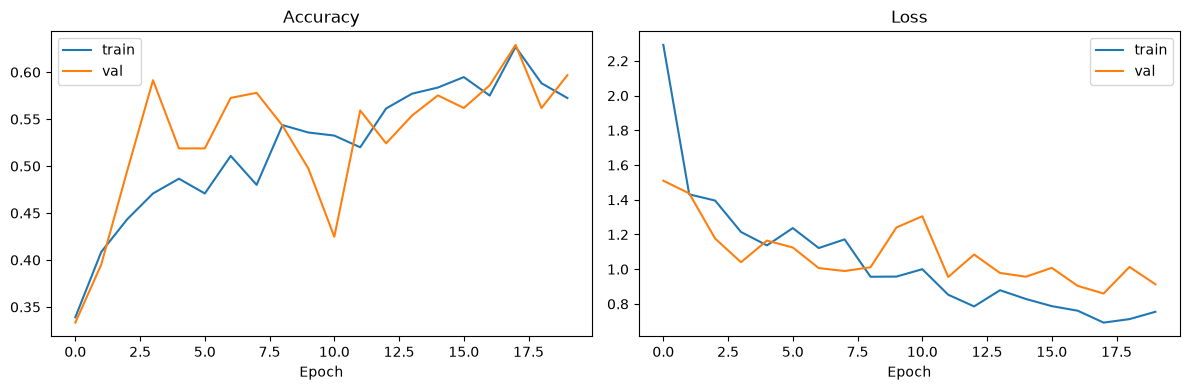

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history["accuracy"], label="train")
ax[0].plot(history.history["val_accuracy"], label="val")
ax[0].set_title("Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(history.history["loss"], label="train")
ax[1].plot(history.history["val_loss"], label="val")
ax[1].set_title("Loss")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()


## 11. (Optional) Stage 2 — Fine-tuning

Unfreezes the **last ~20 layers** of MobileNetV2 and trains with a much lower
learning rate. This usually gives a meaningful accuracy boost, but uses more
VRAM — if you get an OOM error here, skip this section and just use the
Stage 1 model, or drop `BATCH_SIZE` to 8 first.

Run this only after Stage 1 has finished and plateaued.


In [15]:
base_model.trainable = True

# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # much lower LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc", multi_label=True)]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 1,370,693 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [16]:
fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

history_fine = model.fit(
    train_ds_prepped,
    validation_data=val_ds_prepped,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weight_dict,
    callbacks=fine_tune_callbacks
)


Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.5528 - auc: 0.7256 - loss: 2.4869
Epoch 1: val_accuracy improved from None to 0.62097, saving model to ./best_model.keras

Epoch 1: finished saving model to ./best_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 96s 861ms/step - accuracy: 0.5528 - auc: 0.7256 - loss: 2.4869 - val_accuracy: 0.6210 - val_auc: 0.8185 - val_loss: 0.8346
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.5403 - auc: 0.7848 - loss: 1.9250
Epoch 2: val_accuracy did not improve from 0.62097
96/96 ━━━━━━━━━━━━━━━━━━━━ 77s 793ms/step - accuracy: 0.5403 - auc: 0.7848 - loss: 1.9250 - val_accuracy: 0.6075 - val_auc: 0.8222 - val_loss: 0.8448
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.5521 - auc: 0.8215 - loss: 1.5055
Epoch 3: val_accuracy did not improve from 0.62097
96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 745ms/step - accuracy: 0.5521 - auc: 0.8215 - loss: 1.5055 - val_accuracy: 0.6102 - val_auc: 0.7959 - val_loss: 0.8492
Epoch 

## 12. Evaluate on the test set

In [17]:
# Load the best saved checkpoint before final evaluation
best_model = keras.models.load_model(MODEL_SAVE_PATH)

test_loss, test_acc, test_auc = best_model.evaluate(test_ds_prepped)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test AUC:      {test_auc:.4f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 564ms/step - accuracy: 0.6170 - auc: 0.8388 - loss: 0.8440

Test accuracy: 0.6170
Test AUC:      0.8388


In [18]:
# Detailed per-class metrics
y_true = []
y_pred = []

for images, labels in test_ds_prepped:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

        COPD       0.06      0.43      0.10         7
      Normal       0.88      0.53      0.66       240
   Pneumonia       0.00      0.00      0.00         2
Pneumothorax       0.12      0.24      0.16        17
          TB       0.70      0.90      0.79       110

    accuracy                           0.62       376
   macro avg       0.35      0.42      0.34       376
weighted avg       0.77      0.62      0.66       376



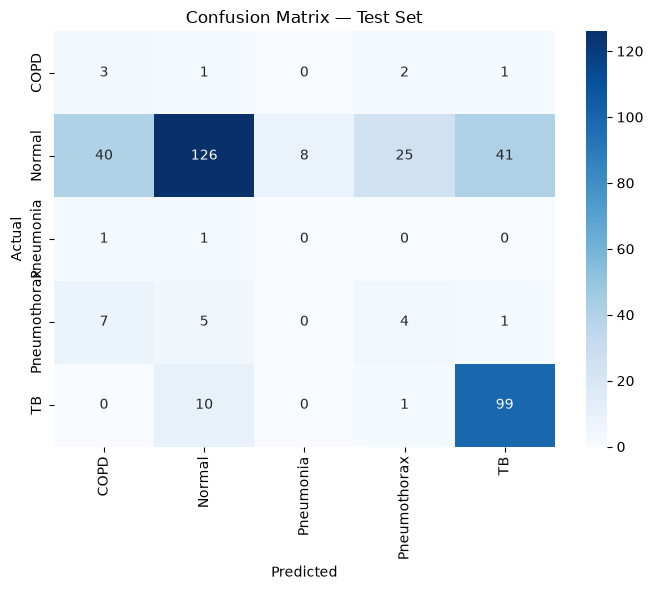

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


## 13. Save the final model

`.keras` format (already saved via checkpointing above) is the modern Keras
format and is what you should use for reloading and inference later.


In [20]:
best_model.save_weights("model.weights.h5")
print(f"Weights saved at: {os.path.abspath('model.weights.h5')}")

# To reload later, rebuild the same architecture in code, then:
#   model.load_weights("model.weights.h5")

Weights saved at: d:\Coding\healzy\xray\model.weights.h5


## Notes on what to check if results look weak

- **If Pneumonia/Pneumothorax/COPD recall is very low** in the classification
  report: this is expected if those classes have few images (as flagged in
  preprocessing). Class weighting helps but can't fully compensate for very
  small classes — the fix is more data for those specific classes, not a
  different architecture.
- **If train accuracy is high but val accuracy is much lower:** the model is
  overfitting — try increasing dropout, adding more augmentation, or reducing
  `EPOCHS_FROZEN`.
- **If both train and val accuracy are low:** try unfreezing more layers in
  Stage 2, or increasing `EPOCHS_FROZEN`.
- **CUDA OOM errors:** drop `BATCH_SIZE` to 8, and skip Stage 2 fine-tuning if
  it still fails there.
